In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключаем библиотеку copy
import copy

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# начальную конфигурацию частиц
# решеточного газа


def Init(L, N_particle):
    # L - размер ячейки
    # N_particle - число частиц
    #              решеточного газа

    # инициализация массивов,
    # используемых размещения
    # координат частиц решеточного газа
    x = np.zeros(N_particle)
    y = np.zeros(N_particle)

    # инициализация массива,
    # используемого для перемещения
    # частиц решеточного газа
    Site = np.zeros([N_particle, N_particle])

    # инициализация счетчика цикла
    i = 0

    # формирование начальной конфигурации
    # частиц решеточного газа
    while i in range(N_particle):
        # вычисление абсциссы и ординаты
        # случайно выбираемого узла
        X_add = int(random.uniform(0, L))
        Y_add = int(random.uniform(0, L))

        # проверка является ли
        # выбранный узел свободным
        if Site[X_add, Y_add] == 0:
            # если узел был свободным,
            # помещаем в него частицу
            Site[X_add, Y_add] = 10**307
            # запоминаем координаты узла,
            # в котором была размещена
            # частица решеточного газа
            x[i] = X_add
            y[i] = Y_add
        i = i + 1

    return x, y, Site

In [ ]:
# Ячейка № 3

# задание функции,
# возвращающей координаты частиц
# решеточного газа на каждом
# шаге метода Монте-Карло
def Move(L, N_particle, N_trial, X_init, Y_init, Site):
    # размещаем в массивах X, Y
    # фактические значения
    # элементов массивов
    # X_init,Y_init
    X = copy.deepcopy(X_init)
    Y = copy.deepcopy(Y_init)

    # размещаем в массиве Sate1
    # фактические значения
    # элементов массива Site
    Site1 = copy.deepcopy(Site)

    # задаем функцию, возвращающую
    # целочисленные значения
    # элементов массива типа float
    def f(x):
        return int(x)

    f2 = np.vectorize(f)

    # инициализация массива z,
    # используемого для хранения
    # координат частиц решеточного газа
    # в момент времени t = 0, а также
    # на каждом шаге метода Монте-Карло
    z = np.zeros([N_particle, 2, N_trial + 1])

    # размещение в массиве z
    # абсцисс частиц
    # начальной конфигурации
    # решеточного газа
    z[:, 0, 0] = X_init[:]
    # размещение в масcиве z
    # ординат частиц
    # начальной конфигурации
    # решеточного газа
    z[:, 1, 0] = Y_init[:]

    # реализация метода Монте-Карло
    for i in range(1, N_trial + 1):
        for j in range(N_particle):
            # случайный выбор номера
            # перемещаемой частицы
            I_trial = int(random.uniform(0, N_particle))

            # сохранение целочисленных значений
            # координат перемещаемой  частицы
            # решеточного газа в переменных
            # X_trial, Y_trial, сответственно
            X_trial = f2(X[I_trial])
            Y_trial = f2(Y[I_trial])

            # случайный выбор направления перемещения
            # частицы решеточного газа
            Direction = int(random.uniform(1, 5))

            # вычисление с учетом
            # периодических граничных условий
            # координат точки, в которую
            # будет перемещена выбранная частица,
            # если данная точка окажется незанятой
            if Direction == 1:
                X_trial = X_trial + 1
                if X_trial > L - 1:
                    X_trial = 1
            if Direction == 2:
                X_trial = X_trial - 1
                if X_trial < 0:
                    X_trial = L - 2
            if Direction == 3:
                Y_trial = Y_trial + 1
                if Y_trial > L - 1:
                    Y_trial = 1
            if Direction == 4:
                Y_trial = Y_trial - 1
                if Y_trial < 0:
                    Y_trial = L - 2

            # проверка является ли
            # новая точка незанятой
            if Site1[X_trial, Y_trial] == 0:
                # освобождение ранее занятого узла
                Site1[f2(X[I_trial]), f2(Y[I_trial])] = 0
                # размещение частицы в занимаемом узле
                X[I_trial] = X_trial
                Y[I_trial] = Y_trial
                Site1[X_trial, Y_trial] = 10**307
        # размещение абсцисс частиц
        # решеточного газа новой конфигурации
        # в массиве z
        z[:, 0, i] = copy.deepcopy(X[:])

        # размещение в масcиве z
        # ординат частиц
        # начальной конфигурации
        # решеточного газа
        # в массиве z
        z[:, 1, i] = copy.deepcopy(Y[:])

    return z

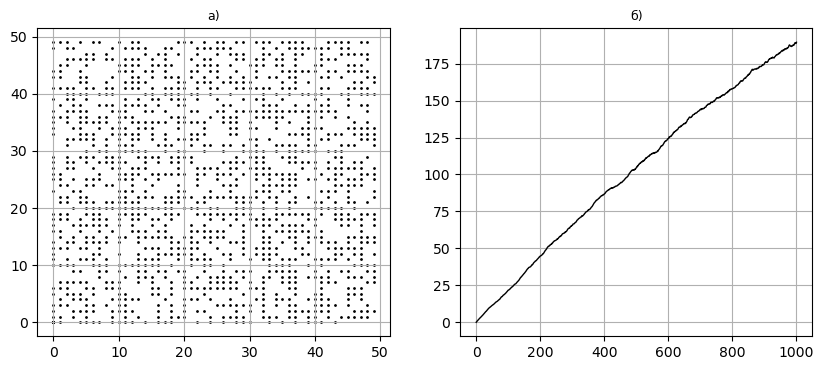

In [4]:
# Ячейка № 4

# моделирование движения
# частиц решеточного газа

# инициализация генератора случайных чисел
random.seed()

# задание размера ячейки
L = 50
# задание числа частиц
# решеточного газа
N_particle = 2 * 10**3

# задание числа шагов
# метода Монте-Карло
N_trial = 10**3

# вычисление начальной конфигурации
# частиц решеточного газа
[X_init, Y_init, Site] = Init(L, N_particle)

# вычисление координат частиц решеточного газа
# на каждом шаге метода Монте-Карло
C = Move(L, N_particle, N_trial, X_init, Y_init, Site)

# инициализация массива dR,
# используемого для вычисления
# мгновенных значений
# среднеквадратического отклонения
dR = np.zeros(N_trial + 1)

# вычисление мгновенных значений
# среднеквадратического отклонения
for i in range(N_trial + 1):
    R2 = 0
    for j in range(N_particle):
        dx = C[j, 0, i] - X_init[j]
        dy = C[j, 1, i] - Y_init[j]
        if abs(dx) > L / 2:
            dx = dx - dx / abs(dx) * L
        if abs(dy) > L / 2:
            dy = dy - dy / abs(dy) * L
        R2 = R2 + dx**2 + dy**2
    dR[i] = R2.item() / N_particle

# визуализация начальной конфигурации
# частиц решеточного газа и зависимости
# cреднеквадратического отклонения
# от номера шага метода Монте-Карло,
# усредненных по ансамблю траекторий
fig = plt.figure(figsize=(10, 4))

ax = plt.subplot(1, 2, 1)
ax.scatter(X_init, Y_init, color="black", s=1)
ax.grid(True)
ax.set_title("а)", fontsize=9)

ax = plt.subplot(1, 2, 2)
ax.plot(dR, "-k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=9)

plt.show()